## Интеллектуальный анализ данных – весна 2025
## Домашнее задание 4: kNN. Линейные модели. Работа с признаками

Правила:

* Домашнее задание оценивается в 10 баллов.

* Можно использовать без доказательства любые результаты, встречавшиеся на лекциях или семинарах по курсу, если получение этих результатов не является вопросом задания.

* Можно использовать любые свободные источники с *обязательным* указанием ссылки на них.

* Плагиат не допускается. При обнаружении случаев списывания, 0 за работу выставляется всем участникам нарушения, даже если можно установить, кто у кого списал.

* Старайтесь сделать код как можно более оптимальным. В частности, будет штрафоваться использование циклов в тех случаях, когда операцию можно совершить при помощи инструментов библиотек, о которых рассказывалось в курсе.  

* Если в задании есть вопрос на рассуждение, то за отсутствие ответа на него балл за задание будет снижен вполовину.

### Задание 1:  Визуализация решающих поверхностей в kNN.

В этом задании мы изобразим решающую поверхность для классификатора kNN, чтобы наглядно увидеть, как классификатор принимает решения для новых объектов. Для простоты будем работать с усеченным датасетом `Palmer Penguins`, содержащим информацию о характеристиках трех видов пингвинов: `Adelie`, `Chinstrap` и `Gentoo`:



*   Species — вид пингвина (целевая переменная).
*   Island — остров, на котором была сделана запись.
*   Clutch Completion — завершенность кладки яиц.
*   Date Egg — закодированная дата откладки яиц (число дней от самой ранней даты в данных).
*   Culmen Length (mm) — длина клюва.
*   Culmen Depth (mm) — глубина клюва.
*   Flipper Length (mm) — длина ласт.
*   Body Mass (g) — масса тела в граммах.
*   Sex — пол особи.
*   Delta 15 N (o/oo) и Delta 13 C (o/oo) — изотопные значения, характеризующие пищевые предпочтения.

Описание полного набора данных и дополнительную информацию о проекте можно найти [здесь](https://allisonhorst.github.io/palmerpenguins/index.html) и [здесь](https://www.kaggle.com/datasets/parulpandey/palmer-archipelago-antarctica-penguin-data?resource=download).

![Palmer Penguins](https://allisonhorst.github.io/palmerpenguins/reference/figures/lter_penguins.png)



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('penguins_data.csv')
data.head(10)

,Species,Island,Clutch Completion,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex,Delta 15 N (o/oo),Delta 13 C (o/oo)
0,Chinstrap,Dream,Yes,382,50.9,19.1,196.0,3550.0,MALE,10.02372,-24.86594
1,Chinstrap,Dream,Yes,741,45.2,17.8,198.0,3950.0,FEMALE,8.88942,-24.49433
2,Gentoo,Biscoe,Yes,744,46.5,13.5,210.0,4550.0,FEMALE,7.99530,-25.32829
3,Chinstrap,Dream,Yes,10,45.2,16.6,191.0,3250.0,FEMALE,9.62357,-24.78984
4,Gentoo,Biscoe,Yes,13,48.4,14.4,203.0,4625.0,FEMALE,8.16582,-26.13971
5,Gentoo,Biscoe,Yes,22,48.1,15.1,209.0,5500.0,MALE,8.45738,-26.22664
6,Gentoo,Biscoe,Yes,13,51.1,16.5,225.0,5250.0,MALE,8.20660,-26.36863
7,Gentoo,Biscoe,No,392,42.7,13.7,208.0,3950.0,FEMALE,8.14567,-26.59467
8,Adelie,Biscoe,Yes,14,39.6,20.7,191.0,3900.0,FEMALE,8.80967,-26.78958
9,Gentoo,Biscoe,Yes,735,46.1,13.2,211.0,4500.0,FEMALE,7.99300,-25.51390


**Задача 1.1 (0.5 балла)** Есть ли в наборе данных пропущенные значения? Если да, то удалите их. Есть ли в наборе данных категориальные признаки? Если да, то закодируйте их самым оптимальным способом. Аргументируйте свой выбор.

In [3]:
data.isna().sum()

Species                 0
Island                  0
Clutch Completion       0
Date Egg                0
Culmen Length (mm)      2
Culmen Depth (mm)       2
Flipper Length (mm)     2
Body Mass (g)           2
Sex                    10
Delta 15 N (o/oo)      14
Delta 13 C (o/oo)      13
dtype: int64

In [4]:
data.dtypes

Species                 object
Island                  object
Clutch Completion       object
Date Egg                 int64
Culmen Length (mm)     float64
Culmen Depth (mm)      float64
Flipper Length (mm)    float64
Body Mass (g)          float64
Sex                     object
Delta 15 N (o/oo)      float64
Delta 13 C (o/oo)      float64
dtype: object

Видим, что пропущенные значения есть, как среди категориальных признаков, так и среди числовых,значит дропнем их.


In [5]:
data.dropna(inplace=True)

In [6]:
data.isna().sum()

Species                0
Island                 0
Clutch Completion      0
Date Egg               0
Culmen Length (mm)     0
Culmen Depth (mm)      0
Flipper Length (mm)    0
Body Mass (g)          0
Sex                    0
Delta 15 N (o/oo)      0
Delta 13 C (o/oo)      0
dtype: int64

Закодируем категориальные признаки вида пингвинов с помощью OrdinalEncoder, тк написано в задании. А для остальных категориальных признаков буду использовать one-hot кодирование, тк это просто и удобно.

In [7]:
data = pd.get_dummies(data, columns=['Island', 'Sex', 'Clutch Completion'], drop_first=True)
data.head(10)

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Sex_FEMALE,Sex_MALE,Clutch Completion_Yes
0,Chinstrap,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,True,False,False,True,True
1,Chinstrap,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,True,False,True,False,True
2,Gentoo,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,False,False,True,False,True
3,Chinstrap,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,True,False,True,False,True
4,Gentoo,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,False,False,True,False,True
5,Gentoo,22,48.1,15.1,209.0,5500.0,8.45738,-26.22664,False,False,False,True,True
6,Gentoo,13,51.1,16.5,225.0,5250.0,8.20660,-26.36863,False,False,False,True,True
7,Gentoo,392,42.7,13.7,208.0,3950.0,8.14567,-26.59467,False,False,True,False,False
8,Adelie,14,39.6,20.7,191.0,3900.0,8.80967,-26.78958,False,False,True,False,True
9,Gentoo,735,46.1,13.2,211.0,4500.0,7.99300,-25.51390,False,False,True,False,True


Целевую категориальную переменную закодируйте в ординальном порядке: Chinstrap = 0, Gentoo = 1, Adelie = 2. Можно воспользоваться [OrdinalEncoder](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OrdinalEncoder.html).

Теперь сохраним информацию о признаках в переменную
`X`, а о целевой переменной – в переменную `y`.

In [8]:
from sklearn import preprocessing
encoder = preprocessing.OrdinalEncoder(categories=[['Chinstrap', 'Gentoo', 'Adelie']], dtype=np.int64)
data["Species"] = encoder.fit_transform(data[["Species"]])
X, y = data.drop('Species', axis=1), data['Species']
data.head(10)

,Species,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Sex_FEMALE,Sex_MALE,Clutch Completion_Yes
0,0,382,50.9,19.1,196.0,3550.0,10.02372,-24.86594,True,False,False,True,True
1,0,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,True,False,True,False,True
2,1,744,46.5,13.5,210.0,4550.0,7.99530,-25.32829,False,False,True,False,True
3,0,10,45.2,16.6,191.0,3250.0,9.62357,-24.78984,True,False,True,False,True
4,1,13,48.4,14.4,203.0,4625.0,8.16582,-26.13971,False,False,True,False,True
5,1,22,48.1,15.1,209.0,5500.0,8.45738,-26.22664,False,False,False,True,True
6,1,13,51.1,16.5,225.0,5250.0,8.20660,-26.36863,False,False,False,True,True
7,1,392,42.7,13.7,208.0,3950.0,8.14567,-26.59467,False,False,True,False,False
8,2,14,39.6,20.7,191.0,3900.0,8.80967,-26.78958,False,False,True,False,True
9,1,735,46.1,13.2,211.0,4500.0,7.99300,-25.51390,False,False,True,False,True


**Задача 1.2 (0.5 балла)** Используя функцию `train_test_split()`, разделите выборку на тренировочную и тестовую, и долю тестовой выборки задайте равной 0.3. Так как разбиение осуществляется случайным образом, не забудьте зафиксировать `np.random.seed()` для воспроизводимости результатов.

Используйте аргумент `stratify` при разбиении. Почему это важно?

In [9]:
from sklearn.model_selection import train_test_split
np.random.seed(52)
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.3, random_state=52, stratify=y)
X_train.head(10)

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Sex_FEMALE,Sex_MALE,Clutch Completion_Yes
66,385,45.8,18.9,197.0,4150.0,8.18658,-26.45978,False,True,False,True,True
270,746,36.5,18.0,182.0,3150.0,9.68933,-24.42280,True,False,True,False,True
69,390,35.5,16.2,195.0,3350.0,8.56192,-25.95541,False,False,True,False,True
1,741,45.2,17.8,198.0,3950.0,8.88942,-24.49433,True,False,True,False,True
6,13,51.1,16.5,225.0,5250.0,8.20660,-26.36863,False,False,False,True,True
279,733,42.8,14.2,209.0,4700.0,7.63452,-25.46327,False,False,True,False,True
106,393,45.5,15.0,220.0,5000.0,8.63604,-26.74890,False,False,False,True,True
166,16,50.0,15.9,224.0,5350.0,8.20042,-26.39677,False,False,False,True,True
336,14,37.7,19.8,198.0,3500.0,9.11066,-26.42563,False,True,False,True,False
317,381,36.5,16.6,181.0,2850.0,9.07878,-25.88156,False,False,True,False,True


Стратификация данных важна, поскольку сохраняет доли классов на тренировочной и тестовых выборках. Что позволяет сохранить репрезентативность данных и уменьшает рандомность в предсказаниях модели

**Задача 1.3 (1 балл)** На тренировочной выборке обучите шесть классификаторов kNN, отличающихся только числом соседей. Для первого классификатора число соседей поставьте равным 1, для второго - 3, для третьего – 5, для четвертого – 10, для пятого – 15 и для шестого – 25 (обратите внимание на параметр `n_neighbours` класса `KNeighborsClassifier`). Для обучения используйте только два признака:  `Flipper Length (mm)` и `Body Mass (g)`  – и евклидово расстояние. Не забудьте масштабировать признаки, например, при помощи модуля `StandardScaler`.


Выведите долю правильных ответов на тренировочной и тестовой выборках для каждого классификатора.

Так перед всей тренировкой стандартизируем наши данные

In [10]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(data=scaler.fit_transform(X_train), columns=X_train.columns)
X_test = pd.DataFrame(data=scaler.transform(X_test), columns=X_test.columns)
X_train.head(10)

,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Delta 15 N (o/oo),Delta 13 C (o/oo),Island_Dream,Island_Torgersen,Sex_FEMALE,Sex_MALE,Clutch Completion_Yes
0,0.063485,0.359698,0.921122,-0.298733,-0.076379,-0.958051,-1.001948,-0.773687,2.721655,-1.022274,1.022274,0.351799
1,1.291916,-1.410370,0.461349,-1.403170,-1.370261,1.730377,1.581390,1.292512,-0.367423,0.978211,-0.978211,0.351799
2,0.080499,-1.600700,-0.458198,-0.445992,-1.111485,-0.286566,-0.362296,-0.773687,-0.367423,0.978211,-0.978211,0.351799
3,1.274902,0.245500,0.359177,-0.225104,-0.335155,0.299334,1.490674,1.292512,-0.367423,0.978211,-0.978211,0.351799
4,-1.202378,1.368447,-0.304940,1.762883,1.346891,-0.922235,-0.886349,-0.773687,-0.367423,-1.022274,1.022274,0.351799
5,1.247679,-0.211291,-1.479917,0.584817,0.635256,-1.945690,0.261846,-0.773687,-0.367423,0.978211,-0.978211,0.351799
6,0.090708,0.302599,-1.071229,1.394737,1.023421,-0.153965,-1.368615,-0.773687,-0.367423,-1.022274,1.022274,0.351799
7,-1.192169,1.159084,-0.611456,1.689254,1.476280,-0.933291,-0.922037,-0.773687,-0.367423,-1.022274,1.022274,0.351799
8,-1.198975,-1.181974,1.380895,-0.225104,-0.917402,0.695133,-0.958638,-0.773687,2.721655,-1.022274,1.022274,-2.842534
9,0.049874,-1.410370,-0.253854,-1.476800,-1.758426,0.638100,-0.268638,-0.773687,-0.367423,0.978211,-0.978211,0.351799


In [11]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
neighbors = [1, 3, 5, 10, 15, 25]
models = []

print('NN\tTrain\tTest')
for k in neighbors:
    knn = KNeighborsClassifier(n_neighbors=k, metric="euclidean")
    knn.fit(X_train[['Flipper Length (mm)','Body Mass (g)']], y_train)
    y_pred = knn.predict(X_train[['Flipper Length (mm)','Body Mass (g)']])
    y_test_pred = knn.predict(X_test[['Flipper Length (mm)','Body Mass (g)']])
    acc = accuracy_score(y_train, y_pred)
    acc_test = accuracy_score(y_test, y_test_pred)
    print(f'{k}\t{acc:.3f}\t{acc_test:.3f}')
    models.append(knn)
    

NN	Train	Test
1	0.960	0.786
3	0.846	0.786
5	0.828	0.786
10	0.806	0.837
15	0.815	0.837
25	0.806	0.816


**Задача 1.4 (0 баллов)** Установите библиотеку `mlxtend` командой ниже. Библиотеку также можно установить из терминала при помощи `pip` или `conda`, как указано [здесь](http://rasbt.github.io/mlxtend/installation/).

In [12]:
!pip install mlxtend

Если всё прошло успешно, то в выводе команды выше вы увидите сообщение вроде "successfully installed", а следующая ячейка выполнится без ошибок.

In [13]:
import mlxtend

**Задача 1.5 (1 балл)** Библиотека `mlxtend` позволяет достаточно просто визуализировать решающие поверхности обученных классификаторов. Изучите [документацию](http://rasbt.github.io/mlxtend/user_guide/plotting/plot_decision_regions/) библиотеки и найдите, как можно построить несколько графиков решающих поверхностей на сетке (decision regions grid). Постройте такую сетку графиков для обученных выше классификаторов.

**Подсказки:**
1. Вы можете использовать готовый код, приведённый в документации, и адаптировать его для нашего случая.
2. Вам могут понадобиться дополнительные библиотеки, которые используются в примере из документации.
3. Обратите внимание на то, как нужно изменить параметры `gridspec.GridSpec()` и `itertools.product()` для нашего числа классификаторов.
4. В функции `plot_decision_region()` используйте `y_train` и нужные столбцы из `X_train`. Возможно, их придётся перевести в формат массива `numpy`.
5. Если в задаче 1.3 вы сохраните обученные классификаторы в список, то не будет необходимости обучать их заново.
6. Построение графика может занять некоторое время – придётся немного подождать!

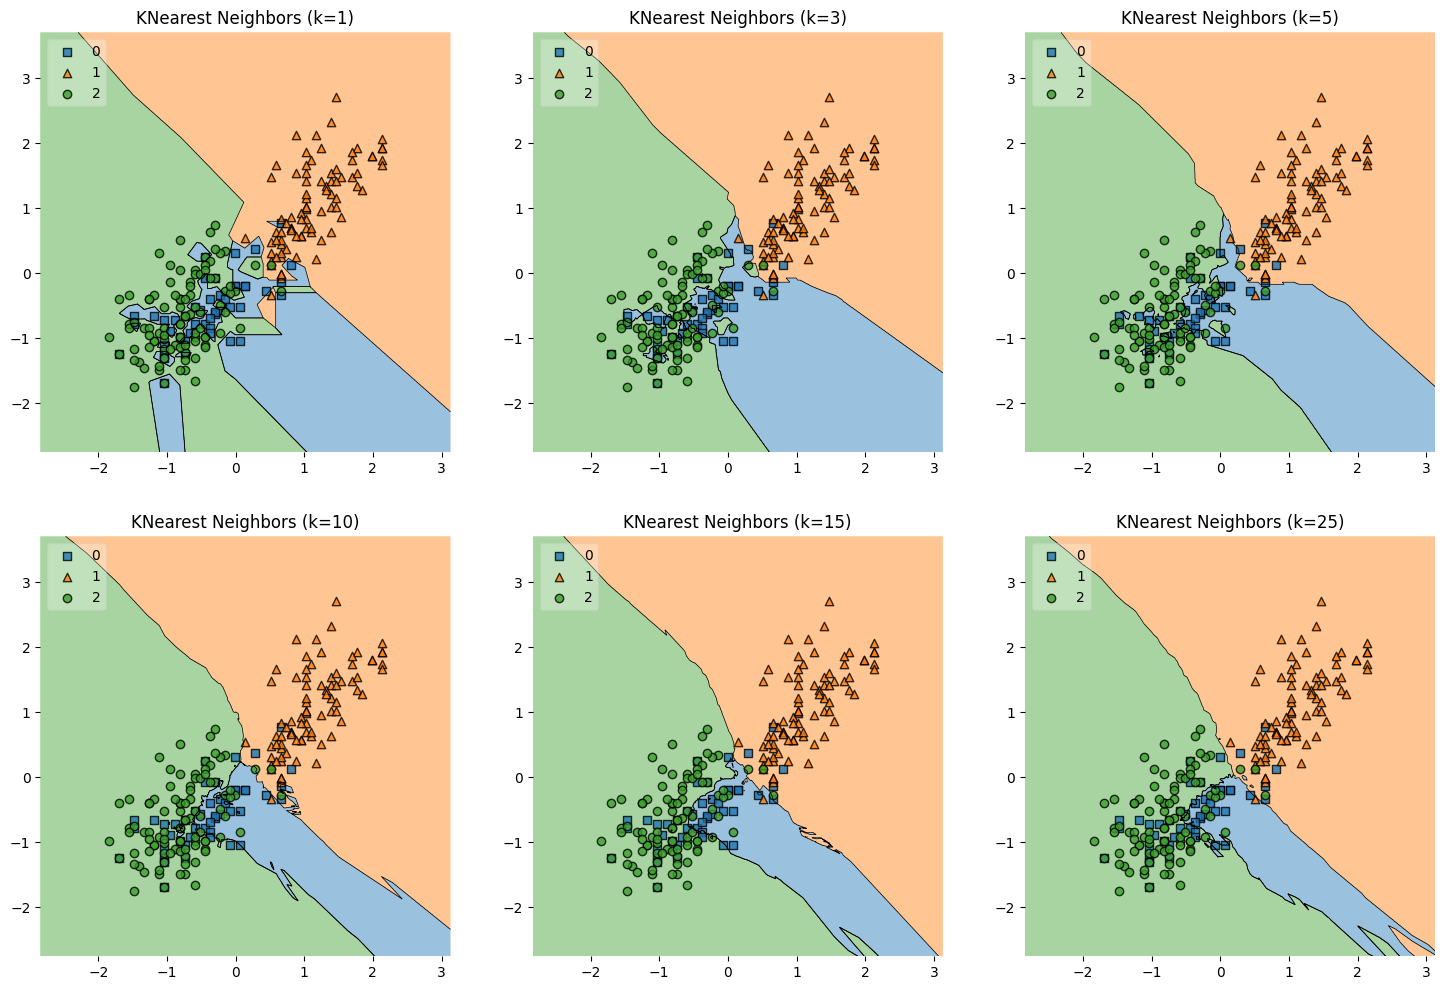

In [14]:
import warnings
import matplotlib.pyplot as plt
from mlxtend.plotting import plot_decision_regions
import matplotlib.gridspec as gridspec
import itertools
gs = gridspec.GridSpec(2, 3)
fig = plt.figure(figsize=(18, 12))

labels = []
for k in neighbors:
    title = f"KNearest Neighbors (k={k})"
    labels.append(title)
    
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning) 
    for model, lab, grd in zip(models,
                            labels,
                            itertools.product([0, 1], [0, 1, 2])):
            
        ax = plt.subplot(gs[grd[0], grd[1]])
        fig = plot_decision_regions(X=X_train[["Flipper Length (mm)", "Body Mass (g)"]].to_numpy(), y=y_train.to_numpy(), clf=model, legend=2)
        plt.title(lab)

plt.show()

**Задача 1.6 (0.5 балла)** Прокомментируйте результаты, полученные в задачах 1.3 и 1.5. Какое число соседей оптимально использовать для обучения классификатора? Поясните ваш выбор при помощи описания геометрии данных и получаемой решающей поверхности. Какие из результатов явно говорят о переобучении модели? Почему?

В задании 1.3 получили не плохие accuracy на тесте и трейне. На мой взгляд наиболее оптимальное число соседей 15, поскольку там вроде как меньше всего островков на решающей поверхности. Также результаты задания 1.3 подтверждают это, поскольку там при $k=15$ то же получили наибольший результат на тестовой выборке.

В нашей ситуации это метод с 1 соседом, при котором модель тупо подстраиввается под подставляемые данные.

### Задание 2. KNN своими руками. 2,5 балла

**Задача 2.1 (2 балла)** В данном задании мы попробуем реализовать алгоритм KNN своими руками, делать мы будем KNN именно для классификации.

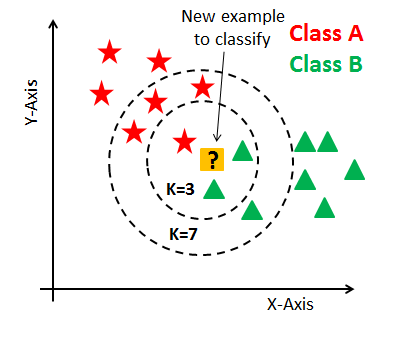

Рекомендации по реализации:
- Используйте `numpy` для представления данных в виде массивов, чтобы минимизировать преобразования.
- Избегайте циклов по всем объектам, по возможности используйте векторизированные операции.
- Обратите внимание на методы [np.linalg.norm()](https://numpy.org/doc/stable/reference/generated/numpy.linalg.norm.html) и [np.argsort()](https://numpy.org/doc/stable/reference/generated/numpy.argsort.html), а также на класс `collections.Counter`.
- Особый плюс, если учтёте обработку возможных ошибок.

In [15]:
import numpy as np
from collections import Counter

class KNN:
    def __init__(self, k:int):
      if k < 1:
        raise ValueError("Соседей должно быть >= 1")
      self.k = k
      self.X = None
      self.y = None
      
    def count_distance(self, x, y):

      # YOUR CODE HERE
      # ヽ(♡‿♡)ノ
      """"Вычисляет евклидово расстояние между точками x и y"""
      return np.linalg.norm(x - y)

    def fit(self, X, y):
      self.X = X
      self.y = y
      
      # YOUR CODE HERE
      # (⌒_⌒;)
  
    def predict(self, X:np.array) -> np.array:
      if self.X is None or self.y is None:
        raise ValueError("Model is not fitted")
      if X.shape[1] != self.X.shape[1]:
        raise ValueError("Wrong number of features")
      
      distances = np.apply_along_axis(lambda x: np.linalg.norm(self.X - x, axis=1), 1, X)
      nearest = np.argsort(distances, axis=1)[:, :self.k]

      return np.apply_along_axis(lambda x: Counter(self.y[x]).most_common(1)[0][0], 1, nearest)

In [16]:
# Не меняйте файл!
def test_knn(KNN):
  knn = KNN(k=1)
  X_train =  np.array([[1, 1], [2, 2]])
  y_train =  np.array([0, 1])
  X_test =  np.array([[1.5, 1.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [0]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[9.5, 9.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5.5, 5.5]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[15, 15]])
  knn.fit(X_train, y_train)
  assert knn.predict(X_test) == [1]

  knn = KNN(k=3)
  X_train = np.array([[1, 1], [2, 2], [3, 3], [4, 4], [5, 5], [6, 6], [7, 7], [8, 8], [9, 9], [10, 10]])
  y_train = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1, 1])
  X_test = np.array([[5, 5], [2, 2]])
  knn.fit(X_train, y_train)
  assert all(knn.predict(X_test) == [1, 0])

In [17]:
# Если тесты эти пройдены, то все верно!
test_knn(KNN)

**Задача 2.2 (0.5 балла)** Протестируйте ваш алгоритм на данных о пингвинах. Выведите лучший получившийся результат на тестовой выборке.

In [18]:
print("NN\t\tMyAcc\tSklearnAcc")
for k in range(1, 25):
    my_model = KNN(k=k)
    my_model.fit(X_train.to_numpy(), y_train.to_numpy())
    y_pred = my_model.predict(X_test.to_numpy())

    sklearn_model = KNeighborsClassifier(n_neighbors=k, metric='euclidean')
    sklearn_model.fit(X_train, y_train)
    y_sklearn_pred = sklearn_model.predict(X_test)

    print(f"{k}\t\t{accuracy_score(y_test, y_pred):.2f}\t\t{accuracy_score(y_test, y_sklearn_pred):.2f}")

NN		MyAcc	SklearnAcc
1		0.99		0.99
2		0.99		0.99
3		1.00		1.00
4		0.99		0.98
5		1.00		1.00
6		0.99		0.99
7		0.99		0.99
8		0.99		0.99
9		0.99		0.99
10		0.99		0.99
11		0.99		0.99
12		0.99		0.99
13		0.99		0.99
14		0.99		0.98
15		0.98		0.98
16		0.98		0.98
17		0.98		0.98
18		0.98		0.98
19		0.98		0.98
20		0.98		0.98
21		0.98		0.98
22		0.98		0.98
23		0.98		0.98
24		0.99		0.98


Лучше всего при 15 соседях.

### Задание 3: Линейная регрессия.

В этом задании мы рассмотрим различные аспекты построения линейной модели. Мы будем работать с одним из классических наборов данных в статистике, содержащим информацию о бриллиантах. Описание можно посмотреть [здесь](https://www.kaggle.com/shivam2503/diamonds).

In [19]:
data = pd.read_csv('diamonds.csv')
data.head(5)

,Unnamed: 0,carat,cut,color,clarity,depth,table,price,x,y,z
0,1,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,2,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,3,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,4,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,5,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75


Мы будем решать задачу предсказания цены бриллианта `price` в зависимости от его характеристик.

**Задача 3.1 (0.2 балла)** Есть ли в наборе данных пропущенные значения? Если да, удалите их.
Есть ли в наборе данных бессмысленные столбцы (признаки, не несущие дополнительной информации)? Если да, то удалите их.

In [20]:
data.isna().any()

Unnamed: 0    False
carat         False
cut           False
color         False
clarity       False
depth         False
table         False
price         False
x             False
y             False
z             False
dtype: bool

In [21]:

data = data.drop('Unnamed: 0', axis=1)
data

,carat,cut,color,clarity,depth,table,price,x,y,z
0,0.23,Ideal,E,SI2,61.5,55.0,326,3.95,3.98,2.43
1,0.21,Premium,E,SI1,59.8,61.0,326,3.89,3.84,2.31
2,0.23,Good,E,VS1,56.9,65.0,327,4.05,4.07,2.31
3,0.29,Premium,I,VS2,62.4,58.0,334,4.20,4.23,2.63
4,0.31,Good,J,SI2,63.3,58.0,335,4.34,4.35,2.75
...,...,...,...,...,...,...,...,...,...,...
53935,0.72,Ideal,D,SI1,60.8,57.0,2757,5.75,5.76,3.50
53936,0.72,Good,D,SI1,63.1,55.0,2757,5.69,5.75,3.61
53937,0.70,Very Good,D,SI1,62.8,60.0,2757,5.66,5.68,3.56
53938,0.86,Premium,H,SI2,61.0,58.0,2757,6.15,6.12,3.74


**Задача 3.2 (0.2 балла)** Линейная регрессия основана на предположении о линейной связи между признаками и целевой переменной, а потому перед выбором переменных для включения в модель имеет смысл проверить, насколько эта связь выполняется. Для следующих пунктов нам также потребуются выборочные корреляции между признаками. Постройте матрицу корреляций между всеми вещественными признаками и целевой переменной (то есть в этой матрице будет $k+1$ строка, где $k$ – количество вещественных признаков).

Какие вещественные признаки имеют наибольшую корреляцию с целевой переменной?

In [22]:
data.select_dtypes(include=np.number).corr()

,carat,depth,table,price,x,y,z
carat,1.000000,0.028224,0.181618,0.921591,0.975094,0.951722,0.953387
depth,0.028224,1.000000,-0.295779,-0.010647,-0.025289,-0.029341,0.094924
table,0.181618,-0.295779,1.000000,0.127134,0.195344,0.183760,0.150929
price,0.921591,-0.010647,0.127134,1.000000,0.884435,0.865421,0.861249
x,0.975094,-0.025289,0.195344,0.884435,1.000000,0.974701,0.970772
y,0.951722,-0.029341,0.183760,0.865421,0.974701,1.000000,0.952006
z,0.953387,0.094924,0.150929,0.861249,0.970772,0.952006,1.000000


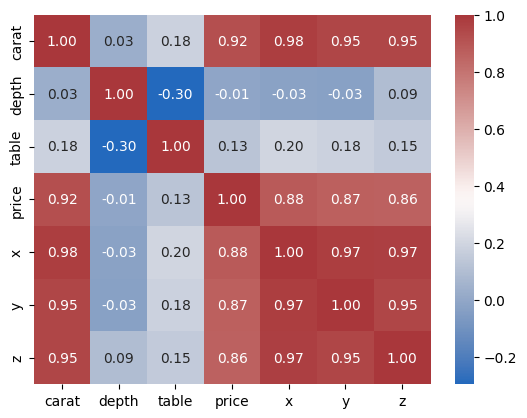

In [23]:
import seaborn as sns

sns.heatmap(data.corr(numeric_only=True), cmap="vlag", annot=True, fmt="0.2f");

Видно, что наибольшую корреляцию с целевой переменной имеют число карат и признаки x,y,z, которые обозначают его размеры.

**Задача 3.3 (0.2 балла)** Так как линейная модель складывает значения признаков с некоторыми весами, нам нужно аккуратно обработать категориальные признаки. Закодируйте категориальные признаки методом OneHot-кодирования (`pd.get_dummies()` или `OneHotEncoder` из `sklearn`).

In [24]:
data = pd.get_dummies(data, columns=["cut", "color", "clarity"], drop_first=True)
data

,carat,depth,table,price,x,y,z,cut_Good,cut_Ideal,cut_Premium,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,326,3.95,3.98,2.43,False,True,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,326,3.89,3.84,2.31,False,False,True,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,327,4.05,4.07,2.31,True,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,334,4.20,4.23,2.63,False,False,True,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,335,4.34,4.35,2.75,True,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,2757,5.75,5.76,3.50,False,True,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,2757,5.69,5.75,3.61,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,2757,5.66,5.68,3.56,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,2757,6.15,6.12,3.74,False,False,True,...,True,False,False,False,False,True,False,False,False,False


**Задача 3.4 (0.2 балла)** Разделите выборку на тренировочную и тестовую. Долю тестовой выборки укажите равной 0.3.

In [25]:
X, y = data.drop(columns=('price')), data['price']
X

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,0.23,61.5,55.0,3.95,3.98,2.43,False,True,False,False,...,False,False,False,False,False,True,False,False,False,False
1,0.21,59.8,61.0,3.89,3.84,2.31,False,False,True,False,...,False,False,False,False,True,False,False,False,False,False
2,0.23,56.9,65.0,4.05,4.07,2.31,True,False,False,False,...,False,False,False,False,False,False,True,False,False,False
3,0.29,62.4,58.0,4.20,4.23,2.63,False,False,True,False,...,False,True,False,False,False,False,False,True,False,False
4,0.31,63.3,58.0,4.34,4.35,2.75,True,False,False,False,...,False,False,True,False,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
53935,0.72,60.8,57.0,5.75,5.76,3.50,False,True,False,False,...,False,False,False,False,True,False,False,False,False,False
53936,0.72,63.1,55.0,5.69,5.75,3.61,True,False,False,False,...,False,False,False,False,True,False,False,False,False,False
53937,0.70,62.8,60.0,5.66,5.68,3.56,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
53938,0.86,61.0,58.0,6.15,6.12,3.74,False,False,True,False,...,True,False,False,False,False,True,False,False,False,False


In [26]:

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=True, random_state=52)


**Задача 3.5 (0.3 балла)** Зачастую при использовании линейных моделей вещественные признаки масштабируются. При этом оценки коэффициентов теряют прямую статистическую интерпретацию ("при увеличении $X_1$ на 1, $y$ увеличивается на $w_1$"), но приобретают свойства, полезные в задачах машинного обучения. В этой задаче стандартизируйте вещественные признаки в тренировочной и тестовой выборках с помощью `StandardScaler`.

Объясните, как это повлияет на интерпретацию коэффициентов линейной регрессии.

In [27]:
from sklearn import preprocessing

scaler = preprocessing.StandardScaler()
X_standart_train = scaler.fit_transform(X_train)
X_standart_test = scaler.fit_transform(X_test)
X_train = pd.DataFrame(data= X_standart_train, columns=X_train.columns)
X_test = pd.DataFrame(data= X_standart_test, columns=X_test.columns)
X_train

,carat,depth,table,x,y,z,cut_Good,cut_Ideal,cut_Premium,cut_Very Good,...,color_H,color_I,color_J,clarity_IF,clarity_SI1,clarity_SI2,clarity_VS1,clarity_VS2,clarity_VVS1,clarity_VVS2
0,-0.207478,3.254085,-1.996268,-0.197692,-0.213035,0.155646,-0.314779,-0.814417,-0.588748,-0.536665,...,-0.426535,-0.334861,-0.234054,-0.182884,-0.563709,-0.456605,-0.421449,1.840075,-0.266795,-0.323295
1,-1.113079,-1.290231,0.686543,-1.337159,-1.260102,-1.390553,-0.314779,-0.814417,-0.588748,1.863359,...,-0.426535,-0.334861,-0.234054,-0.182884,-0.563709,-0.456605,-0.421449,-0.543456,-0.266795,3.093152
2,1.372057,0.177933,-0.654863,1.351271,1.370545,1.378549,-0.314779,-0.814417,-0.588748,1.863359,...,-0.426535,-0.334861,-0.234054,-0.182884,-0.563709,-0.456605,-0.421449,-0.543456,-0.266795,3.093152
3,-0.818232,1.785921,-1.101998,-0.954369,-0.896657,-0.743960,3.176829,-0.814417,-0.588748,-0.536665,...,-0.426535,-0.334861,4.272524,-0.182884,-0.563709,-0.456605,-0.421449,1.840075,-0.266795,-0.323295
4,-1.113079,0.457583,0.686543,-1.426180,-1.407210,-1.362440,-0.314779,-0.814417,1.698519,-0.536665,...,-0.426535,-0.334861,-0.234054,-0.182884,-0.563709,-0.456605,-0.421449,1.840075,-0.266795,-0.323295
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
37753,-0.818232,-0.031805,-1.101998,-0.838642,-0.836083,-0.828299,-0.314779,1.227872,-0.588748,-0.536665,...,-0.426535,-0.334861,-0.234054,-0.182884,-0.563709,-0.456605,-0.421449,-0.543456,3.748203,-0.323295
37754,0.213731,0.177933,-0.207727,0.389846,0.392706,0.408661,-0.314779,1.227872,-0.588748,-0.536665,...,2.344474,-0.334861,-0.234054,-0.182884,-0.563709,2.190077,-0.421449,-0.543456,-0.266795,-0.323295
37755,-0.502325,-2.059269,0.686543,-0.295615,-0.308223,-0.519059,-0.314779,-0.814417,1.698519,-0.536665,...,-0.426535,-0.334861,-0.234054,-0.182884,1.773965,-0.456605,-0.421449,-0.543456,-0.266795,-0.323295
37756,-0.839292,0.737233,-0.207727,-0.963271,-0.888004,-0.842355,-0.314779,-0.814417,-0.588748,1.863359,...,-0.426535,-0.334861,-0.234054,-0.182884,-0.563709,-0.456605,-0.421449,-0.543456,3.748203,-0.323295


Изменение признака $x$ при стандартизации происходит следующим образом:
$$\frac{\alpha x_i-m_i}{\sigma_i}$$
Можно дать грубую оценку, что при изменении оригинального 
i-го признака в $\alpha$ раз масштабированный признак измениться в $\alpha\sigma$ раз.

**Задача 3.6 (0.2 балла)** Оцените линейную регрессию на тренировочной выборке. Выведите среднеквадратичную ошибку на тренировочной и тестовой выборках.

In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
y_train_pred = model.predict(X_train)

mse = mean_squared_error(y_test, y_pred)
print(f"Train MSE: {mean_squared_error(y_train, y_train_pred):.2f}")
print(f"Test MSE: {mse:.2f}")

Train MSE: 1283859.07
Test MSE: 1266330.73


**Задача 3.7 (0.3 балла)** Изучите [документацию](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html) модуля `LinearRegression` и выведите полученные оценки коэффициентов. Назовите вещественные переменные, оценки коэффициентов которых по модулю на порядок превышают оценки прочих вещественных переменных.

In [29]:
model.coef_
list(zip(X_train.columns[np.argsort(np.abs(model.coef_))[::-1]], np.sort(np.abs(model.coef_))[::-1]))

[('carat', 5279.54797521416),
 ('clarity_VS2', 1805.9780203332662),
 ('clarity_VS1', 1655.2132687316341),
 ('clarity_SI1', 1581.8630134727537),
 ('clarity_VVS2', 1465.5918431505881),
 ('clarity_VVS1', 1252.2997236729004),
 ('x', 1075.7714856461523),
 ('clarity_SI2', 1033.5342142918755),
 ('clarity_IF', 946.5357903788661),
 ('color_J', 520.2384786715805),
 ('color_I', 435.51098178973666),
 ('cut_Ideal', 422.51671830555665),
 ('cut_Premium', 348.48024078204065),
 ('color_H', 347.0336247956457),
 ('cut_Very Good', 316.2304042962575),
 ('color_G', 195.37649527372199),
 ('cut_Good', 179.90756541169415),
 ('color_F', 103.90119810146525),
 ('depth', 96.27560615401947),
 ('color_E', 78.07548075158728),
 ('table', 65.80878560931674),
 ('z', 28.767314375342995),
 ('y', 0.7983394470620576)]

Можно заметить, что на порядки превышают свои значения признаки `carat` и `x`

**Задача 3.8 (0.5 балла)** Как можно заметить из анализа корреляционной матрицы в задаче 3.3, между некоторыми признаками имеется сильная корреляция, что может быть индикатором проблемы *мультиколлинеарности*. Различия в порядке коэффициентов, выявленные в предыдущей задаче также намекают на её присутствие. Как известно, для решения этой проблемы можно либо исключить некоторые признаки из модели, либо использовать регуляризацию. Мы воспользуемся вторым вариантом.

Вспомним, что смысл регуляризации заключается в том, чтобы изменить функцию потерь так, чтобы устранить проблемы, появляющиеся из-за мультиколлинеарности. При L1-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\sum_{i=1}^k|w_i|
$$

Такая модель называется Lasso-регрессией.

При L2-регуляризации предлагается минимизировать следующую функцию потерь:

$$
\|y - X\hat{w}\|^2 + \alpha\|w\|^2
$$

Такая модель называется Ridge-регрессией.

Обучите Lasso-регрессию и Ridge-регрессию, установив гиперпараметр регуляризации равным 10. Для этого используйте модули `Lasso` и `Ridge` из `sklearn`. Сильно ли уменьшились веса? Сделайте вывод о том, насколько сильно проблема мультиколлинеарности проявлялась в изначальной регрессии.

In [30]:
from sklearn.linear_model import Lasso, Ridge
lasso = Lasso(alpha=10)
lasso.fit(X_train, y_train)
list(zip(X_train.columns[np.argsort(np.abs(lasso.coef_))[::-1]], np.sort(np.abs(lasso.coef_))[::-1]))

[('carat', 4772.319633091879),
 ('clarity_VS2', 1110.7033730403045),
 ('clarity_VS1', 1054.6758387597542),
 ('clarity_VVS2', 977.4257147677966),
 ('clarity_SI1', 872.7864387429036),
 ('clarity_VVS1', 835.3301817611066),
 ('clarity_IF', 645.7388737853915),
 ('x', 610.8850447246056),
 ('color_J', 462.2103549768218),
 ('clarity_SI2', 414.8722666524681),
 ('color_I', 362.5143291889444),
 ('color_H', 273.5057256898973),
 ('cut_Ideal', 217.67543303047117),
 ('cut_Premium', 162.80004734330106),
 ('cut_Very Good', 146.3271081869329),
 ('color_G', 118.30996533018543),
 ('depth', 100.911840463002),
 ('table', 76.61538193152766),
 ('cut_Good', 55.506507281469645),
 ('color_F', 36.57258349637393),
 ('z', 30.817093461453695),
 ('color_E', 7.495949433722321),
 ('y', 0.0)]

In [31]:
ridge = Ridge(alpha=10)
ridge.fit(X_train, y_train)
list(zip(X_train.columns[np.argsort(np.abs(ridge.coef_))[::-1]], np.sort(np.abs(ridge.coef_))[::-1]))

[('carat', 5240.8232832985095),
 ('clarity_VS2', 1777.264750103618),
 ('clarity_VS1', 1630.5948297727489),
 ('clarity_SI1', 1552.3622430465396),
 ('clarity_VVS2', 1445.7617924977606),
 ('clarity_VVS1', 1235.6049020335704),
 ('x', 1033.3591386686119),
 ('clarity_SI2', 1008.2654891144592),
 ('clarity_IF', 934.6600237042807),
 ('color_J', 519.0003091496385),
 ('color_I', 434.15982019391737),
 ('cut_Ideal', 423.5279455004717),
 ('cut_Premium', 349.38120126518294),
 ('color_H', 346.08955607305916),
 ('cut_Very Good', 317.4120756031449),
 ('color_G', 194.86142193299025),
 ('cut_Good', 180.37249093234368),
 ('color_F', 103.67679359503221),
 ('depth', 94.38077632673703),
 ('color_E', 77.62916743932892),
 ('table', 65.96591982180063),
 ('z', 32.609629044946495),
 ('y', 1.1722964951412045)]

Видно, что коэффициенты не сильно изменились

**Задача 3.9 (0.5 балла)** Как обсуждалось на семинарах, Lasso-регрессию можно использовать для отбора наиболее информативных признаков. Для следующих значений параметра регуляриазции $\alpha$: 0.1, 1, 10, 100, 200 –  обучите Lasso- и Ridge-регрессии и постройте график измненения евклидовой нормы весов (`np.linalg.norm()` от вектора оценок коэффициентов) в зависимости от параметра $\alpha$. Как известно, норма является численной характеристикой величины вектора, а потому по норме можно судить о том, насколько большие элементы содержит вектор оценок коэффициентов.

Какой метод сильнее снижает норму коэффициентов? Поясните, почему Lasso-регрессию часто используют для отбора признаков.

In [32]:
alpha = [ 0.1, 1, 10, 100, 200]
weights_lasso = []
weights_ridge = []
for a in alpha:
    lasso = Lasso(alpha= a)
    ridge = Ridge(alpha= a)
    lasso.fit(X_train, y_train)
    ridge.fit(X_train, y_train)
    weights_lasso.append(np.linalg.norm(lasso.coef_))
    weights_ridge.append(np.linalg.norm(ridge.coef_))

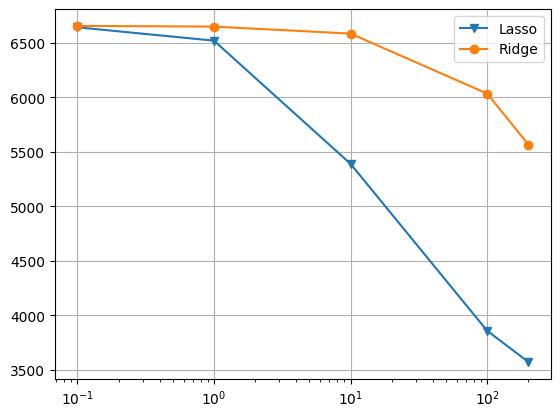

In [33]:
fig, ax = plt.subplots()
ax.plot(alpha, weights_lasso, label= 'Lasso', marker='v')
ax.plot(alpha, weights_ridge, label= 'Ridge', marker='o')

ax.grid()
ax.legend()
ax.set_xscale('log')


В нашем случае `Lasso` метод сильнее снижает норму коэффициентов.

`Lasso` регуляризация имеет очень хорошее свойство — её применение приводит к тому, что у признаков, которые не оказывают большого влияния на ответ, вес в результате оптимизации получается равным 0. Да и в целом, как можно заметить по графику и сравнению коэффициентов выше, `Lasso` сильнее уменьшает коэффициенты. Именно по этим причинам `Lasso` часто используют для отбора признаков.

**Задача 3.10 (0.5 балла)**
В зависимости от значения параметра $\alpha$ в Lasso-регрессии зануляются разные оценки коэффициентов. Оптимальное значение $\alpha$ можно подобрать, например, при помощи кросс-валидации по тренировочной выборке.

Для проведения кросс-валидации можно использовать модуль `LassoCV`. Этот модуль принимает список значений $\alpha$ (параметр `alphas`) и при обучении проводит кросс-валидацию для каждого значения из этого списка, сохраняя MSE на каждом участке кросс-валидации (количество участков – параметр `cv`) в матрицу ошибок (то есть итоговая матрица будет иметь размер `len(alphas)` $\times$ `cv`). После обучения модели матрицу ошибок можно получить, обратившись к атрибуту `.mse_path_`.

Заметим, что модель может использовать $\alpha$ не в том порядке, в котором вы подаёте их в функцию: для определения порядка используйте атрибут `.alphas_` Установите количество участков для кросс-валидации (параметр `cv`) равным 5.

Усредните ошибки для каждого значения $\alpha$ (то есть по строкам матрицы ошибок) и выберите то значение, которое даёт наибольшее качество.

In [34]:
from sklearn.linear_model import LassoCV
lcv = LassoCV(alphas=alpha, cv= 5, random_state=52, max_iter=10000)
lcv.fit(X_train, y_train)
lcv.mse_path_

array([[2076181.84098266, 2065133.11427488, 2324232.33216684,
        2180402.89333196, 2172015.24155448],
       [1715853.2834055 , 1754989.16383598, 1942504.37112514,
        1795447.37178238, 1791615.94487421],
       [1298171.40308259, 1359876.31135811, 1430880.61684584,
        1330409.46222512, 1318560.39533828],
       [1252557.48703378, 1304856.27758782, 1349613.50239847,
        1287987.61866917, 1249359.85007803],
       [1253049.92268799, 1304977.92817599, 1346643.50884716,
        1288893.08264548, 1248547.42163057]])

In [36]:
pd.DataFrame({"alpha": lcv.alphas_, "mse": lcv.mse_path_.mean(axis=1)}).sort_values(by="mse")

,alpha,mse
4,0.1,1.288422e+06
3,1.0,1.288875e+06
2,10.0,1.347580e+06
1,100.0,1.800082e+06
0,200.0,2.163593e+06


Наибольшее количество дало `alpha` 0.1. Выберу его

**Задача 3.11 (0.5 балла)** Обучите итоговую Lasso-регрессию с выбранным параметром $\alpha$ на тренировочной выборке. Выведите полученные коэффициенты и прокомментируйте, какие признаки оказались неинформативными, а какие – наиболее информативными. Приведите возможное смысловое объяснение этого результата.

In [38]:
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
pd.DataFrame({"coef": model.coef_}, index=X_train.columns).sort_values(by="coef", ascending=False, key=np.abs)


,coef
carat,5274.495463
clarity_VS2,1798.920127
clarity_VS1,1649.118960
clarity_SI1,1574.663821
clarity_VVS2,1460.637613
clarity_VVS1,1248.067340
x,-1070.490897
clarity_SI2,1027.254244
clarity_IF,943.482625
color_J,-519.658080


Самые информативные признаки, влияющие на стоимость бриллианта
- **Карат** — вес бриллианта. Причина здесь очевидна: чем больше вес, тем больше сам бриллиант, смотрится массивнее, а значит и стоит дороже.
- **Чистота бриллианта**. Чем чище бриллиант, тем дороже он стоит.
- **Длина бриллианта**. Возможно, чем большая длина бриллианта нарушает «правильные» пропорции бриллианта, следовательно его вид, следовательно его стоимость.
- **Цвет** — оказывает несравнимое с остальными информативными признаками влияние, однако тоже следует учитывать его учитывать. «Плохие» цвета негативно влияют на стоимость бриллианта.

НЕ информативные признаки
- **Ширина бриллианта** (настолько незначительный признак, что он даже занулился) — возможная причина может заключаться в том, что этот параметр можно однозначно определить остальные параметры размера (см. формулу для depth). Также, возможно, что этот параметр в принципе не особо важен для определения цены бриллианта.
- **Ширина верхушки бриллианта** — вероятная причина та же, что и для общей ширины.
- **Огранка** — хоть и не самый неинформативный признак из всех, имеет достаточно малые коэффициенты. Возможная причина заключается в том, что можно проводить повторную огранку бриллиантов.

**Задача 3.12 (0.4 балла)** Сделайте предсказания обученной Lasso-регрессии на тестовой выборке и сравните среднеквадратичную ошибку с ошибкой обычной линейной регрессии из задачи 3.7. Какую модель лучше использовать для предсказаний? Приведите возможное объяснение, почему одна модель оказалась лучше другой.

In [39]:
model = Lasso(alpha=0.1)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
best_mse = mean_squared_error(y_test, y_pred)
print("Lasso MSE:", best_mse)
print("Linreg without regularization MSE:", mse)
print("Delta:", mse - best_mse)

Lasso MSE: 1266303.5744565015
Linreg without regularization MSE: 1266330.733279263
Delta: 27.158822761382908
